In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
TRUE_W = 3.0
TRUE_B = 2.0

NUM_EXAMPLES = 201

x = tf.linspace(-2,2,NUM_EXAMPLES)
x = tf.cast(x, tf.float32)

def f(x):
    return x * TRUE_W + TRUE_B

noise = tf.random.normal(shape=[NUM_EXAMPLES])

y = f(x) + noise

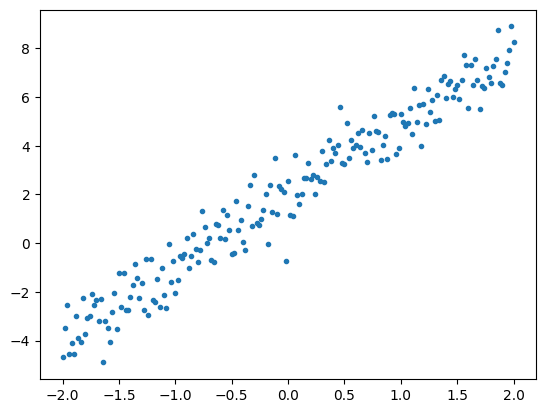

In [3]:
plt.plot(x, y, '.')
plt.show()

In [4]:
class MyModel(tf.Module):
    def __init__(self):
        super().__init__()
        self.w = tf.Variable(5.0)
        self.b = tf.Variable(0.0)

    def __call__(self, x):
        return self.w * x + self.b


model = MyModel()
print("Variables", model.variables)
assert model(3.0).numpy() == 15.0

Variables (<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=0.0>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=5.0>)


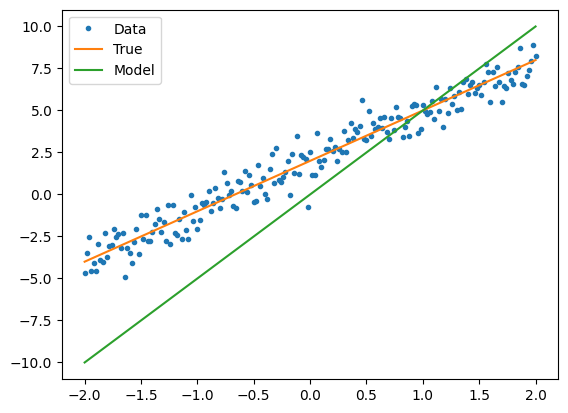

In [5]:
plt.plot(x, y, '.', label='Data')
plt.plot(x, f(x), label='True')
plt.plot(x, model(x), label='Model')
plt.legend()
plt.show()


In [6]:
def loss(target_y, predicted_y):
    return tf.reduce_mean(tf.square(target_y - predicted_y))

In [7]:
def train(model, x, y, learning_rate):
    with tf.GradientTape() as t:
        current_loss = loss(y, model(x))
    dw, db = t.gradient(current_loss, [model.w, model.b])
    model.w.assign_sub(learning_rate * dw)
    model.b.assign_sub(learning_rate * db)

In [8]:
model = MyModel()

weights = []
biases = []
epochs = range(10)

def report(model, loss):
    return f"W={model.w.numpy():.3f}, b={model.b.numpy():.3f}, loss={loss:.3f}"


def training_loop(model, x, y):
    for epoch in epochs:
        train(model, x, y, learning_rate=0.1)
        weights.append(model.w.numpy())
        biases.append(model.b.numpy())
        current_loss = loss(y, model(x))
        print(f"Epoch {epoch}, {report(model, current_loss)}")

In [9]:
current_loss = loss(y, model(x))
print(f"Starting:")
print("   ", report(model, current_loss))
training_loop(model, x, y)

Starting:
    W=5.000, b=0.000, loss=10.270
Epoch 0, W=4.448, b=0.400, loss=6.186
Epoch 1, W=4.044, b=0.721, loss=3.853
Epoch 2, W=3.749, b=0.977, loss=2.510
Epoch 3, W=3.534, b=1.182, loss=1.730
Epoch 4, W=3.376, b=1.346, loss=1.273
Epoch 5, W=3.261, b=1.477, loss=1.004
Epoch 6, W=3.177, b=1.582, loss=0.844
Epoch 7, W=3.116, b=1.666, loss=0.747
Epoch 8, W=3.071, b=1.733, loss=0.689
Epoch 9, W=3.038, b=1.787, loss=0.654


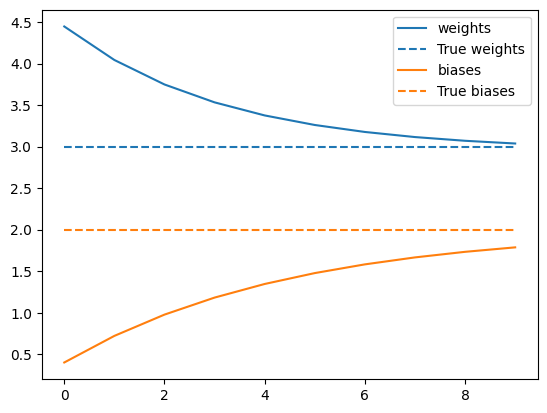

In [10]:
plt.plot(epochs, weights, label="weights", color=colors[0])
plt.plot(epochs, [TRUE_W] * len(epochs), '--', label='True weights', color=colors[0])
plt.plot(epochs, biases, label="biases", color=colors[1])
plt.plot(epochs, [TRUE_B] * len(epochs), '--', label='True biases', color=colors[1])
plt.legend()
plt.show()

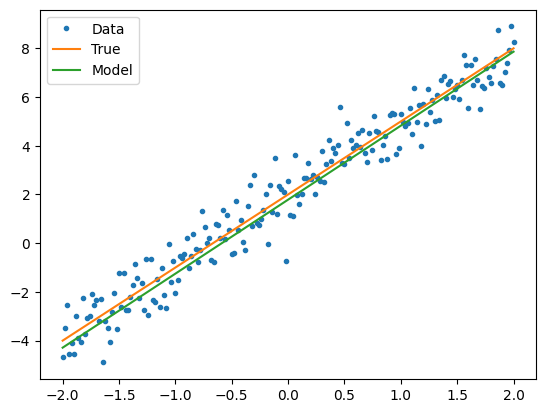

In [11]:
plt.plot(x, y, '.', label='Data')
plt.plot(x, f(x), label='True')
plt.plot(x, model(x), label='Model')
plt.legend()
plt.show()